In [6]:
import warnings
warnings.filterwarnings('ignore')

from collections import defaultdict
import pickle
import numpy as np
import os
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathos.multiprocessing import ProcessPool as Pool
from utils import simulate_one, get_prior, get_model_and_rbg_data, compute_cgm_metrics, compute_params_metrics, print_summary
from sbi.inference import NPE
from sbi.utils.user_input_checks import process_prior

import matplotlib.dates as mdates


In [31]:
from scipy.stats import wasserstein_distance

import matplotlib.transforms as transforms
import string

from matplotlib.ticker import LogLocator

def add_letters(fig, ax, dx=-35/72., dy=15/72.):
    
    letterkwargs = dict(weight='bold', va='top', ha='left')

    offset = transforms.ScaledTranslation(
            dx, dy, fig.dpi_scale_trans)

    for idx in range(len(ax)):
        ax[idx].text(0, 1, string.ascii_lowercase[idx], transform=ax[idx].transAxes + offset, 
                    **letterkwargs)


def coverage(samples, true_val, lower=2.5, upper=97.5):
    """Check if true_val lies within the credible interval."""
    lower_bound = np.percentile(samples, lower)
    upper_bound = np.percentile(samples, upper)
    return lower_bound <= true_val <= upper_bound


def compute_params_metrics(samples, true_val):
    """
    Compute:
    - abs(median - true)
    - wasserstein distance
    - coverage
    """
    samples = np.asarray(samples)
    median_est = np.median(samples)
    abs_err_median = abs(median_est - true_val)
    wd = wasserstein_distance(samples, [true_val])
    cov = coverage(samples, true_val)
    return [abs_err_median, wd, cov]

# Load trained model

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load model and prior
model, rbg_data = get_model_and_rbg_data('./data/data_day_1.csv', './data/patient_info.csv')
custom_prior = get_prior(model, rbg_data, device)
prior, _, _ = process_prior(custom_prior)

inference = NPE(prior=prior, device=device)
density_estimator = torch.load('./trained_models/pretrained_density_estimator.pt', map_location=device)
posterior = inference.build_posterior(density_estimator)


Using device: cpu


# Parameter evaluation

In [8]:
param_list = ['Gb', 'SG', 'p2', 'ka2', 'kd', 'kempt', 'SI', 'kabs', 'beta']
test_theta, test_x = torch.load('./data/simulated/precomputed_test_data.pt')

our_metrics = defaultdict(list)
replay_metrics = defaultdict(list)
map_metrics = defaultdict(list)

for idx in range(50):
    with open(f'./results/mcmc/mcmc_mcmc_data_day_1_{idx}.pkl', 'rb') as f:
        replay_bg_pred = pickle.load(f)

    with open(f'./results/map/map_map_data_day_1_{idx}.pkl', 'rb') as f:
        map_pred = pickle.load(f)
    
    if os.path.isfile(f'./sbi_results/SBI_res_{idx}.pt'):
        samples, _ = torch.load(f'./sbi_results/SBI_res_{idx}.pt')
    else:
        samples, samples_x = [], []
        while len(samples) < 1000:
            batch_samples = posterior.sample((1000,), x=test_x[idx].to(device)).to(device)
            log_probs = prior.log_prob(batch_samples) 
            # Mask out samples with -inf log prob
            mask = torch.isfinite(log_probs)
            batch_samples = batch_samples[mask]
        
            input_data = [
                (batch_samples[i].cpu().numpy(), model, rbg_data)
                for i in range(batch_samples.shape[0])
            ]
            with Pool() as pool:
                results = pool.map(simulate_one, input_data)
            for i, result in enumerate(results):
                if result[1] is not None:
                    samples_x.append(result[1])
                    samples.append(batch_samples[i])
        torch.save([samples, samples_x], f'./sbi_results/SBI_res_{idx}_test.pt')
    
    samples_np = torch.stack(samples)[:1000, :9].numpy()
    
    true_theta = test_theta[idx][:9].numpy()

    for i, param in enumerate(param_list):
        our_param_samples = samples_np[:, i]
        replay_param_samples = replay_bg_pred['draws'][param]['samples_1000']
        map_param_samples = map_pred['draws'][param] * np.ones_like(replay_param_samples)
        true_param_val = true_theta[i]

        our_metrics[param].append(compute_params_metrics(our_param_samples, true_param_val))
        replay_metrics[param].append(compute_params_metrics(replay_param_samples, true_param_val))
        map_metrics[param].append(compute_params_metrics(map_param_samples, true_param_val))


In [9]:
latex_labels = ["$G_b$", "$S_G$", "$p_2$", "$k_{a2}$", "$k_d$", "$k_{empt}$", "$SI$", "$k_{abs}$", "$\\beta$"]

data = {
    "Parameter": [],
    "Method": [],
    "Abs Error": [],
    "MAD": [],
    "Coverage": []
}

for param, latex_label in zip(param_list, latex_labels):
    our_summary = np.mean(our_metrics[param], axis=0)
    replay_summary = np.mean(replay_metrics[param], axis=0)
    map_summary = np.mean(map_metrics[param], axis=0)
    
    for method, summary in zip(["MAP", "ReplayBG", "SBI"], [map_summary, replay_summary, our_summary]):
        data["Parameter"].append(latex_label)
        data["Method"].append(method)
        data["Abs Error"].append(summary[0])
        data["MAD"].append(summary[1])
        data["Coverage"].append(summary[2] * 100)

df = pd.DataFrame(data)
df

,Parameter,Method,Abs Error,MAD,Coverage
0,$G_b$,MAP,17.259551,17.259551,0.0
1,$G_b$,ReplayBG,17.405746,17.391250,4.0
2,$G_b$,SBI,4.437649,7.205065,94.0
3,$S_G$,MAP,0.023463,0.023463,0.0
4,$S_G$,ReplayBG,0.018177,0.018290,8.0
5,$S_G$,SBI,0.007794,0.011827,96.0
6,$p_2$,MAP,0.001793,0.001793,0.0
7,$p_2$,ReplayBG,0.001472,0.001549,42.0
8,$p_2$,SBI,0.000741,0.001046,88.0
9,$k_{a2}$,MAP,0.006645,0.006645,0.0


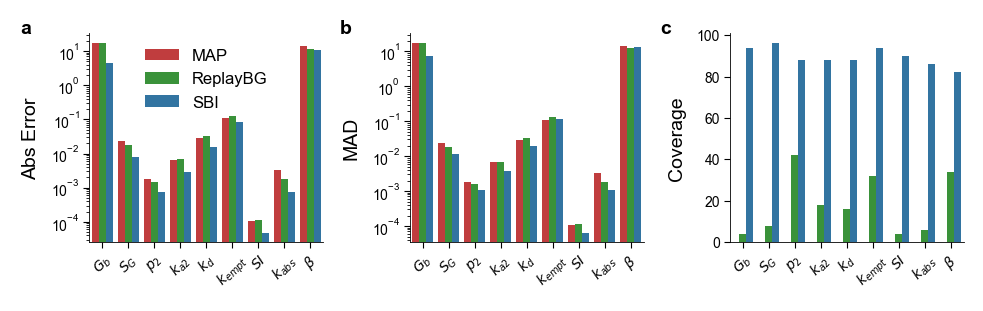

In [38]:
metrics = ["Abs Error", "MAD", "Coverage"]
TEXTWIDTH = 12.19826 / 2.54  # cm → inch
FIGWIDTH = TEXTWIDTH

with plt.style.context("./plot_style.txt"):

    fig, axes = plt.subplots(1, 3, figsize=(FIGWIDTH, 0.3 * FIGWIDTH), sharex=True, layout='constrained')
    palette = {"MAP": "tab:red", "ReplayBG": "tab:green", "SBI": "tab:blue"}

    for ax, metric in zip(axes, metrics):
        sns.barplot(data=df, x="Parameter", y=metric, hue="Method", ax=ax, palette=palette)
        ax.set_xlabel("")
        ax.set_ylabel(metric)
        # ax.set_title(metric, fontsize=10)
        plt.setp(ax.get_xticklabels(), rotation=45, ha='center')
        ax.tick_params(axis='x', labelsize=5)
        ax.tick_params(axis='y', labelsize=5)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.grid(False)



        if metric in ["Abs Error", "MAD"] and df[metric].max() > 10:
            ax.set_yscale("log")

            ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs='auto', numticks=10))
            ax.yaxis.set_minor_formatter(plt.NullFormatter())  # Hide minor tick labels

        # Shared legend
        handles, labels = ax.get_legend_handles_labels()
        ax.get_legend().remove()

        if metric == "Abs Error":
            ax.legend(handles, labels, frameon=False)

    # # Shared legend
    # handles, labels = axes[0].get_legend_handles_labels()
    # for ax in axes:
    #     ax.get_legend().remove()

    # fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False, fontsize=9.5,
    #         bbox_to_anchor=(0.5, 1.17), bbox_transform=fig.transFigure)

    add_letters(fig, axes, dx=-25/72., dy=5/72.) 

    plt.savefig("plots/benchmark_metrics_1x3.pdf", bbox_inches='tight')
    plt.show()


## Posterior visualization

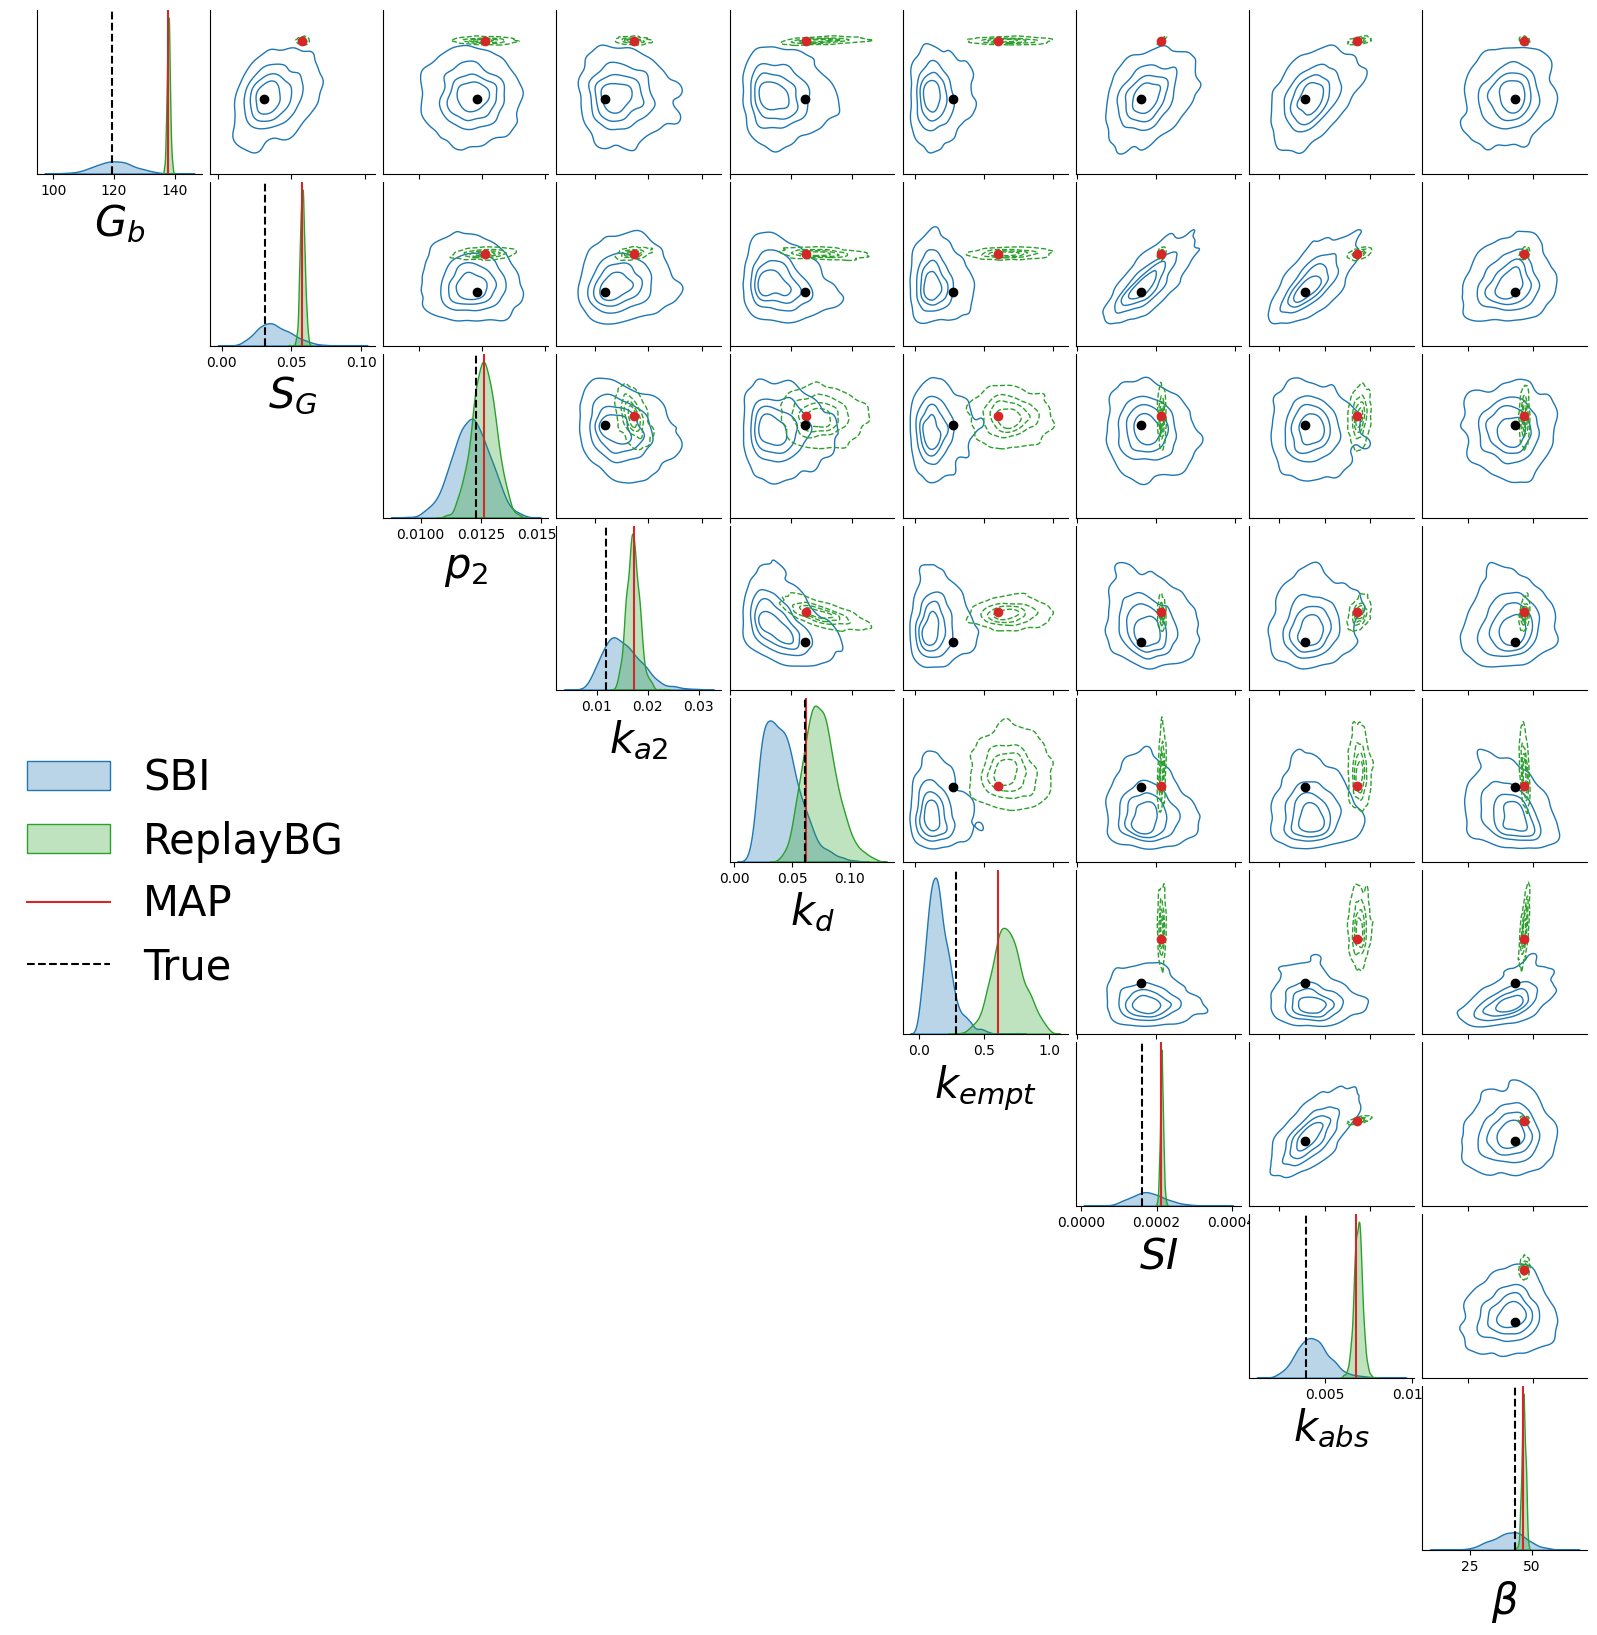

In [6]:
idx = 1

with open(f'./results/mcmc/mcmc_mcmc_data_day_1_{idx}.pkl', 'rb') as f:
    replay_bg_pred = pickle.load(f)

with open(f'./results/map/map_map_data_day_1_{idx}.pkl', 'rb') as f:
    map_pred = pickle.load(f)

samples, _ = torch.load(f'./sbi_results/SBI_res_{idx}.pt')
samples_np = torch.stack(samples)[:1000, :9].numpy()
true_theta = test_theta[idx][:9].numpy()

replay_param_samples = np.vstack([
    replay_bg_pred['draws'][param]['samples_1000'] for param in param_list
]).T

map_param_samples = np.vstack([
    map_pred['draws'][param] * np.ones_like(replay_bg_pred['draws'][param]['samples_1000'])
    for param in param_list
]).T[0]

n_params = samples_np.shape[1]
fig, axes = plt.subplots(n_params, n_params, figsize=(20, 20))
plt.subplots_adjust(hspace=0.05, wspace=0.05)

for i in range(n_params):
    for j in range(n_params):
        ax = axes[i, j]
        if j < i:
            ax.axis('off')
            continue

        if i == j:
            sns.kdeplot(samples_np[:, i], ax=ax, color='tab:blue', fill=True, alpha=0.3, label='SBI')
            sns.kdeplot(replay_param_samples[:, i], ax=ax, color='tab:green', fill=True, alpha=0.3, label='ReplayBG')
            ax.axvline(map_param_samples[i], color='tab:red', linestyle='-', label='MAP')
            ax.axvline(true_theta[i], color='black', linestyle='--', label='True')
            ax.set_xlabel(latex_labels[i], fontsize=30)
            if i == 0:
                ax.legend(frameon=False, fontsize=30, loc='lower center', bbox_to_anchor=(0.9, -5.2))
        else:
            sns.kdeplot(x=samples_np[:, j], y=samples_np[:, i], ax=ax, color='tab:blue', levels=5, linewidths=1)
            sns.kdeplot(x=replay_param_samples[:, j], y=replay_param_samples[:, i], ax=ax, color='tab:green', levels=5, linewidths=1, linestyles='--')
            ax.plot(map_param_samples[j], map_param_samples[i], marker='o', color='tab:red')
            ax.plot(true_theta[j], true_theta[i], marker='o', color='black')

            if i < n_params - 1:
                ax.set_xticklabels([])

        ax.set_yticks([])
        ax.set_ylabel('')
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

plt.savefig("plots/posterior.pdf", bbox_inches='tight')
plt.show()


# CGM evaluation

In [7]:
def load_or_simulate_replay_samples(idx, model_idx, rbg_data_idx, param_list, extended=False, noise=False):
    suffix = '_extended' if extended else ''
    suffix = '_noise' if noise else suffix
    cache_path = f'./results/replay/mcmc_data_day_1_{idx}{suffix}.pt'
    
    if not extended and not noise and os.path.isfile(f'./results/workspaces/mcmc_data_day_1_{idx}_step_2a.pkl'):
        with open(f'./results/workspaces/mcmc_data_day_1_{idx}_step_2a.pkl', 'rb') as f:
            data = pickle.load(f)
        replay_x_samples = np.stack(data['cgm']['realizations'])
    elif os.path.isfile(cache_path):
        replay_x_samples = torch.load(cache_path)
    else:
        with open(f'./results/mcmc/mcmc_mcmc_data_day_1_{idx}.pkl', 'rb') as f:
            replay_bg_pred = pickle.load(f)
        replay_samples = np.stack([replay_bg_pred['draws'][param]['samples_1000'] for param in param_list]).T
        input_data = [(replay_samples[i], model_idx, rbg_data_idx) for i in range(replay_samples.shape[0])]
        with Pool() as pool:
            results = pool.map(simulate_one, input_data)
        replay_x_samples = np.stack([r[1] for r in results if r[0] is not None and r[1] is not None])
        torch.save(replay_x_samples, cache_path)
    return replay_x_samples

def load_or_simulate_map_median(idx, model_idx, rbg_data_idx, param_list, extended=False, noise=False):
    suffix = '_extended' if extended else ''
    suffix = '_noise' if noise else suffix
    cache_path = f'./results/replay/map_data_day_1_{idx}{suffix}.pt'
    
    if not extended and not noise and os.path.isfile(f'./results/workspaces/map_data_day_1_{idx}_step_2a.pkl'):
        with open(f'./results/workspaces/map_data_day_1_{idx}_step_2a.pkl', 'rb') as f:
            data = pickle.load(f)
        map_x_median = data['cgm']['realizations'][0]
    elif os.path.isfile(cache_path):
        map_x_median = torch.load(cache_path)
    else:
        with open(f'./results/map/map_map_data_day_1_{idx}.pkl', 'rb') as f:
            map_pred = pickle.load(f)
        map_samples = np.array([map_pred['draws'][param] for param in param_list])
        map_x_median = simulate_one((map_samples, model_idx, rbg_data_idx))[1]
        torch.save(map_x_median, cache_path)
    return map_x_median

def load_or_simulate_sbi_results(idx, model_idx, rbg_data_idx, extended=False, noise=False):
    suffix = '_extended' if extended else ''
    suffix = '_noise' if noise else suffix
    cache_path = f'./sbi_results/SBI_res_{idx}{suffix}.pt'

    if not os.path.isfile(cache_path):
        samples, _ = torch.load(f'./sbi_results/SBI_res_{idx}.pt')
        input_data = [(samples[i].numpy(), model_idx, rbg_data_idx) for i in range(len(samples))]
        with Pool() as pool:
            results = pool.map(simulate_one, input_data)
        pred_x_samples = [r[1] for r in results if r[0] is not None and r[1] is not None]
        torch.save([samples, pred_x_samples], cache_path)
    else:
        _, pred_x_samples = torch.load(cache_path)
    return np.stack(pred_x_samples)


In [8]:
def get_noise_meals(cache_path):
    # Prepare noise meals if not exists
    if not os.path.isfile(cache_path):
        data = pd.read_csv('./data/data_day_1.csv')
        data.t = pd.to_datetime(data['t'])
        noise_meals = []
        for idx in range(50):
            data_copy = data.copy()
            mask = data_copy['cho_label'].isin({'D', 'L', 'S'})
            noise_std = 0.1
            noise = np.random.normal(loc=0.0, scale=noise_std, size=mask.sum()) * data_copy.loc[mask, 'cho']
            data_copy.loc[mask, 'cho'] = np.clip(data_copy.loc[mask, 'cho'] + noise, a_min=0, a_max=None)
            noise_meals.append(data_copy.cho.values)
        noise_meals = np.stack(noise_meals)
        torch.save(noise_meals, cache_path)
    else:
        noise_meals = torch.load(cache_path)
    return noise_meals

def evaluate(test_theta, test_x, param_list, extended=False, noise=False):
    our_mard, our_rmsd = [], []
    replay_mard, replay_rmsd = [], []
    map_mard, map_rmsd = [], []
    
    if noise:
        noise_meals = get_noise_meals('./data/noise_meals.pt')
        
    for idx in range(test_x.shape[0]):

        model_idx, rbg_data_idx = get_model_and_rbg_data(
            './data/data_day_1_extended.csv' if extended else './data/data_day_1.csv',
            './data/patient_info.csv',
            test_x[idx].numpy(),
            cho=noise_meals[idx] if noise else None
        )

        # Handle true extended or noise data caching
        if extended or noise:
            true_cache_path = f'./data/simulated/data_day_1_{idx}{"_extended" if extended else "_noise"}.pt'
            if os.path.isfile(true_cache_path):
                true_x = torch.load(true_cache_path)
            else:
                true_x = simulate_one((test_theta[idx].numpy(), model_idx, rbg_data_idx))[1]
                torch.save(true_x, true_cache_path)
            if extended:
                true_x = true_x[test_x.shape[1]:]  # Use only extended part
        else:
            true_x = test_x[idx].numpy()
            
        pred_x_samples = load_or_simulate_sbi_results(idx, model_idx, rbg_data_idx, extended=extended, noise=noise)
        pred_x_median = np.median(pred_x_samples, axis=0)
        if extended:
            pred_x_median = pred_x_median[test_x.shape[1]:]  # Use only extended part

        replay_x_samples = load_or_simulate_replay_samples(idx, model_idx, rbg_data_idx, param_list, extended=extended, noise=noise)
        replay_x_median = np.median(replay_x_samples, axis=0)
        if extended:
            replay_x_median = replay_x_median[test_x.shape[1]:]  # Use only extended part
            
        map_x_median = load_or_simulate_map_median(idx, model_idx, rbg_data_idx, param_list, extended=extended, noise=noise)
        if extended:
            map_x_median = map_x_median[test_x.shape[1]:]  # Use only extended part

        # Compute metrics
        mard, rmsd = compute_cgm_metrics(pred_x_median, true_x)
        our_mard.append(mard)
        our_rmsd.append(rmsd)

        mard, rmsd = compute_cgm_metrics(replay_x_median, true_x)
        replay_mard.append(mard)
        replay_rmsd.append(rmsd)

        mard, rmsd = compute_cgm_metrics(map_x_median, true_x)
        map_mard.append(mard)
        map_rmsd.append(rmsd)

    print_summary('MAP', map_mard, map_rmsd)
    print_summary('ReplayBG', replay_mard, replay_rmsd)
    print_summary('SBI', our_mard, our_rmsd)



## Setting 1

In [9]:
evaluate(test_theta, test_x, param_list, extended=False, noise=False)


MAP MARD: 12.35 ± 4.48%, RMSD: 16.10 ± 6.45
ReplayBG MARD: 6.74 ± 2.10%, RMSD: 8.75 ± 1.95
SBI MARD: 11.03 ± 4.68%, RMSD: 14.05 ± 4.91


## Setting 2

In [10]:
evaluate(test_theta, test_x, param_list, extended=True, noise=False)


MAP MARD: 20.69 ± 11.63%, RMSD: 23.26 ± 9.15
ReplayBG MARD: 17.56 ± 11.58%, RMSD: 19.02 ± 9.22
SBI MARD: 11.56 ± 6.03%, RMSD: 13.56 ± 6.31


## Setting 3

In [11]:
evaluate(test_theta, test_x, param_list, extended=False, noise=True)

MAP MARD: 17.11 ± 10.15%, RMSD: 20.09 ± 9.22
ReplayBG MARD: 14.30 ± 9.13%, RMSD: 16.26 ± 7.95
SBI MARD: 12.72 ± 8.13%, RMSD: 14.75 ± 7.26


## CGM Visualization

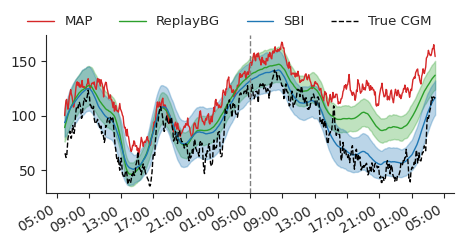

In [12]:

sns.set_style("ticks")

# Figure dimensions
TEXTWIDTH = 12.19826 / 2.54  # Convert cm to inches
FIGWIDTH = TEXTWIDTH
FIGHEIGHT = 0.55 * FIGWIDTH

extended_data = pd.read_csv(f'./data/data_day_1_extended.csv')
extended_data.t = pd.to_datetime(extended_data['t'])
# Select index of interest
idx = 15

# --- Load predictions from SBI ---
_, pred_x_samples = torch.load(f'./sbi_results/SBI_res_{idx}_extended.pt')

# --- Load predictions from ReplayBG (posterior sampling) ---
replay_x_samples = torch.load(f'./results/replay/mcmc_data_day_1_{idx}_extended.pt')
    
map_replay_x = torch.load(f'./results/replay/map_data_day_1_{idx}_extended.pt')
true_x = torch.load(f'./data/simulated/data_day_1_{idx}_extended.pt')
# --- Compute means and standard deviations ---
pred_mean = np.stack(pred_x_samples).mean(axis=0)
pred_std = np.stack(pred_x_samples).std(axis=0)

replay_mean = np.stack(replay_x_samples).mean(axis=0)
replay_std = np.stack(replay_x_samples).std(axis=0)

# --- High-contrast, colorblind-friendly colors ---
COLOR_SBI = 'tab:blue'        # Blue
COLOR_REPLAY = 'tab:green'     # Orange/Vermilion
COLOR_MAP = 'tab:red'        # Dark Green
COLOR_GT = 'black'         # Black

# --- Plotting ---
fig, ax = plt.subplots(figsize=(FIGWIDTH, FIGHEIGHT), layout='constrained')

# ReplayBG MAP estimate (baseline)
ax.plot(extended_data.t, map_replay_x, label='MAP', color=COLOR_MAP, linewidth=1)

# ReplayBG posterior (baseline)
ax.plot(extended_data.t, replay_mean, label='ReplayBG', color=COLOR_REPLAY, linewidth=1)
ax.fill_between(extended_data.t, replay_mean - replay_std, replay_mean + replay_std, color=COLOR_REPLAY, alpha=0.3)

# SBI prediction (method under test)
ax.plot(extended_data.t, pred_mean, label='SBI', color=COLOR_SBI, linewidth=1)
ax.fill_between(extended_data.t, pred_mean - pred_std, pred_mean + pred_std, color=COLOR_SBI, alpha=0.3)

# Ground truth
ax.plot(extended_data.t, true_x, label='True CGM', color=COLOR_GT, linewidth=1, linestyle='--')

# Style and formatting
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=4))
plt.gcf().autofmt_xdate()
mid_time = extended_data.t[len(extended_data.t) // 2]
ax.axvline(mid_time, color='gray', linestyle='--', linewidth=1)

# Legend at the top
ax.legend(loc='upper center', bbox_to_anchor=(0.45, 1.2), ncol=4, fontsize=9.5, frameon=False)

# Save
plt.tight_layout()
plt.savefig('plots/cgm_plot.pdf', format='pdf', bbox_inches='tight')
